# Business entity resolution: decision-oriented EDA

Run cells from top to bottom. The six source files contain roughly 24 million records, so the overview scans every row in chunks. Detailed pair and retrieval work uses a **deterministic sample** of S1 records, a sampled S2/S3 candidate pool, and **all true partners of those sampled S1 records**. Candidate recall measured on this reduced pool is an optimistic diagnostic; it is **not full-corpus blocking recall**. No raw files are changed and no model is trained.

Recommended environment: `pandas`, `numpy`, `scikit-learn`, `rapidfuzz`, `matplotlib`. Increase the sampling divisors below if memory is limited.

## 1. Setup and load the data

Find the dataset, verify all seven TSV files and their columns, and set reproducible sample sizes. The actual folder in this repository is `data/raw/student_resource/dataset`; an alternate `student_resources` spelling is also checked.

In [2]:
from pathlib import Path
from collections import Counter, defaultdict
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from rapidfuzz.distance import Levenshtein, JaroWinkler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn import config_context

SEED = 2026
CHUNK_SIZE = 100_000
S1_SAMPLE_DIVISOR = 1_000       # ~0.1% of S1 training rows
CANDIDATE_SAMPLE_DIVISOR = 100  # ~1% of S2/S3 rows, plus every sampled S1 true partner
MAX_EXAMPLES = 15
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'docs/problem.md').exists()), None)
assert ROOT is not None, 'Open this notebook from within the repository.'
DATASET_CANDIDATES = [ROOT / 'data/raw/student_resource/dataset',
                      ROOT / 'data/raw/student_resources/dataset',
                      Path('/data/raw/student_resources/dataset')]
DATASET = next((p for p in DATASET_CANDIDATES if p.is_dir()), None)
assert DATASET is not None, f'Dataset missing; checked: {DATASET_CANDIDATES}'
paths = {(split, source): DATASET / split / f'{split}_source{source}.tsv'
         for split in ('train', 'test') for source in (1, 2, 3)}
truth_path = DATASET / 'train/train_ground_truth.tsv'
expected = {'entity_id', 'business_name', 'business_address', 'country'}
for key, path in paths.items():
    assert path.is_file(), f'Missing {path}'
    header = set(pd.read_csv(path, sep='\t', nrows=0).columns)
    assert expected == header, f'Unexpected columns in {path}: {header}'
assert truth_path.is_file()
assert set(pd.read_csv(truth_path, sep='\t', nrows=0).columns) == {'source1_entity_id', 'matched_entity_ids'}
display(pd.DataFrame([{'split': a, 'source': f'S{b}', 'path': str(p)} for (a, b), p in paths.items()]))
for key in [('train', 1), ('train', 2), ('train', 3), ('test', 1), ('test', 2), ('test', 3)]:
    print(key)
    display(pd.read_csv(paths[key], sep='\t', nrows=3))
display(pd.read_csv(truth_path, sep='\t', nrows=3))

,split,source,path
0,train,S1,/Users/vedansh/amazon-ml-challenge/data/raw/st...
1,train,S2,/Users/vedansh/amazon-ml-challenge/data/raw/st...
2,train,S3,/Users/vedansh/amazon-ml-challenge/data/raw/st...
3,test,S1,/Users/vedansh/amazon-ml-challenge/data/raw/st...
4,test,S2,/Users/vedansh/amazon-ml-challenge/data/raw/st...
5,test,S3,/Users/vedansh/amazon-ml-challenge/data/raw/st...


('train', 1)


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US


('train', 2)


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India


...

('test', 2)


,entity_id,business_name,business_address,country
0,S2-192345572,Brahma Infosoft,"COIMATORE COLONY, HUNSUR TQMYSORE DIST., Karna...",India
1,S2-566025912,Marina Ecole France Sarl,"63 R. DE DIEPPE, LILLE, Hauts-de-France",France
2,S2-158121477,SCI Ptit Àmicale,"18 RUE JEN ZAY, Dunkerque, Nord",France


('test', 3)


,entity_id,business_name,business_address,country
0,S3-462677478,मॉडर्न फाइनेंस,"No 10 Enkay Square, 448A, Udyog Vihar Phase V,...",India
1,S3-374810425,Shri Sai Infratech Co,"3/115, East Delhi, DL",India
2,S3-198586129,Fractales Amis Groupe S.A.S,"23 Rue Icmre, La Teste-de-buch, Gironde",France


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"


**How to read this:** Confirm the displayed files, tab-separated columns, source ID prefixes, and example field values. A one-column table usually means the tab delimiter was missed. Stop and correct the path or schema before continuing.

## 2. Basic dataset overview

Scan every source row in chunks for counts, missingness, lengths, token structure, Unicode, country distribution, and duplicate IDs. Only a small deterministic row sample is retained for later work. This scan is the most time-consuming part of the notebook.

In [3]:
def selected_rows(df, divisor):
    # Stable hash of the ID gives the same sample across notebook runs.
    return df.loc[(pd.util.hash_pandas_object(df['entity_id'], index=False).to_numpy(dtype='uint64') % divisor) == 0].copy()

def scan_source(path, split, source, sample_divisor):
    sums = Counter()
    countries = Counter()
    by_country = defaultdict(Counter)
    id_numbers = []
    samples = []
    for chunk in pd.read_csv(path, sep='\t', chunksize=CHUNK_SIZE, dtype='string', keep_default_na=False):
        n = len(chunk)
        ids = chunk['entity_id'].astype(str)
        valid = ids.str.fullmatch(rf'S{source}-[0-9]+').fillna(False)
        sums['bad_prefix_or_id'] += int((~valid).sum())
        id_numbers.append(pd.to_numeric(ids.str.extract(r'-([0-9]+)$', expand=False), errors='coerce').fillna(-1).to_numpy(dtype='int64'))
        name = chunk['business_name'].astype(str)
        address = chunk['business_address'].astype(str)
        country = chunk['country'].astype(str)
        name_missing = name.str.strip().eq('')
        address_missing = address.str.strip().eq('')
        country_missing = country.str.strip().eq('')
        name_len, address_len = name.str.len(), address.str.len()
        name_tokens = name.str.count(r'\S+')
        address_tokens = address.str.count(r'\S+')
        numeric_tokens = address.str.count(r'(?<!\w)\d+(?!\w)')
        non_ascii = name.str.contains(r'[^\x00-\x7f]', regex=True) | address.str.contains(r'[^\x00-\x7f]', regex=True)
        sums.update({'rows': n, 'missing_name': int(name_missing.sum()),
                     'missing_address': int(address_missing.sum()), 'missing_country': int(country_missing.sum()),
                     'name_chars': int(name_len.sum()), 'address_chars': int(address_len.sum()),
                     'name_tokens': int(name_tokens.sum()), 'address_tokens': int(address_tokens.sum()),
                     'numeric_tokens': int(numeric_tokens.sum()), 'non_ascii': int(non_ascii.sum())})
        countries.update(country.value_counts().to_dict())
        summary_chunk = pd.DataFrame({'country': country, 'rows': 1, 'missing_name': name_missing.astype('int8'),
                                      'missing_address': address_missing.astype('int8'), 'name_chars': name_len,
                                      'address_chars': address_len, 'name_tokens': name_tokens,
                                      'address_tokens': address_tokens, 'numeric_tokens': numeric_tokens,
                                      'non_ascii': non_ascii.astype('int8')})
        for label, group in summary_chunk.groupby('country', dropna=False):
            by_country[str(label)].update({col: int(group[col].sum()) for col in group.columns if col != 'country'})
        samples.append(selected_rows(chunk, sample_divisor))
    numeric_ids = np.concatenate(id_numbers)
    unique_count = len(np.unique(numeric_ids))
    row = {'split': split, 'source': f'S{source}', 'rows': sums['rows'], 'unique_ids': unique_count,
           'duplicate_ids': sums['rows'] - unique_count, 'bad_prefix_or_id': sums['bad_prefix_or_id']}
    for field in ('name', 'address', 'country'):
        row[f'missing_{field}_pct'] = 100 * sums[f'missing_{field}'] / sums['rows']
    for field in ('name_chars', 'address_chars', 'name_tokens', 'address_tokens', 'numeric_tokens'):
        row[f'avg_{field}'] = sums[field] / sums['rows']
    row['non_ascii_pct'] = 100 * sums['non_ascii'] / sums['rows']
    return row, countries, by_country, pd.concat(samples, ignore_index=True)

overview_rows, country_counts, country_sums, sampled = [], {}, {}, {}
for (split, source), path in paths.items():
    divisor = S1_SAMPLE_DIVISOR if source == 1 else CANDIDATE_SAMPLE_DIVISOR
    row, counts, grouped, sample = scan_source(path, split, source, divisor)
    overview_rows.append(row)
    country_counts[(split, source)] = counts
    country_sums[(split, source)] = grouped
    sampled[(split, source)] = sample
    print(f'{split} S{source}: {row["rows"]:,} scanned, {len(sample):,} sampled')
overview = pd.DataFrame(overview_rows).set_index(['split', 'source'])
display(overview.round(2))
country_table = pd.DataFrame({f'{a} S{b}': counts for (a, b), counts in country_counts.items()}).fillna(0).astype(int)
display(country_table)
display(overview.loc[(overview['duplicate_ids'] > 0) | (overview['bad_prefix_or_id'] > 0)])

train S1: 2,206,821 scanned, 2,150 sampled
train S2: 5,034,616 scanned, 50,308 sampled
train S3: 5,285,603 scanned, 52,794 sampled
test S1: 1,732,544 scanned, 1,752 sampled
test S2: 4,887,273 scanned, 49,224 sampled
test S3: 5,082,316 scanned, 50,852 sampled


rows  unique_ids  duplicate_ids  bad_prefix_or_id  \
split source                                                         
train S1      2206821     2206821              0                 0   
      S2      5034616     5034616              0                 0   
      S3      5285603     5285603              0                 0   
test  S1      1732544     1732544              0                 0   
      S2      4887273     4887273              0                 0   
      S3      5082316     5082316              0                 0   

              missing_name_pct  missing_address_pct  missing_country_pct  \
split source                                                               
train S1                   0.0                 0.00                  0.0   
      S2                   0.0                 3.36                  0.0   
      S3                   0.0                 3.33                  0.0   
test  S1                   0.0                 0.00                  0.0   
      S2                   0.0                 2.65                  0.0   
      S3                   0.0                 2.68                  0.0   

              avg_name_chars  avg_address_chars  avg_name_tokens  \
split source                                                       
train S1               24.03              52.07             3.55   
      S2               25.10              46.23             3.50   
      S3               25.20              46.71             3.53   
test  S1               23.84              57.21             3.52   
      S2               25.70              50.41             3.59   
      S3               25.66              48.74             3.60   

              avg_address_tokens  avg_numeric_tokens  non_ascii_pct  
split source                                                         
train S1                    8.03                1.35           0.03  
      S2                    7.29                1.29          21.98  
      S3                    7.17                1.30          18.72  
test  S1                    8.59                1.36           5.86  
      S2                    7.80                1.35          29.68  
      S3                    7.51                1.33          25.91

,train S1,train S2,train S3,test S1,test S2,test S3
US,1323633,3016817,3170056,663106,1871330,1945701
India,883188,2017799,2115547,809986,2312565,2405000
France,0,0,0,259452,703378,731615


,,rows,unique_ids,duplicate_ids,bad_prefix_or_id,missing_name_pct,missing_address_pct,missing_country_pct,avg_name_chars,avg_address_chars,avg_name_tokens,avg_address_tokens,avg_numeric_tokens,non_ascii_pct
split,source,,,,,,,,,,,,,


**How to read this:** Check duplicate IDs and malformed prefixes first. Compare missing fields and text lengths across sources, then compare train and test country counts. Large source differences may call for source-aware features; test-only countries call for generic normalization. The table covers all records, while later pair analyses use samples.

## 3. Ground-truth match structure

Count match multiplicity for **all** S1 labels. Save only the true relationships needed by the sampled S1 anchors for later joins.

In [4]:
sample_s1 = sampled[('train', 1)].drop_duplicates('entity_id').copy()
sample_s1_ids = set(sample_s1['entity_id'].astype(str))
truth_counts = Counter()
sample_truth = {}
truth_rows = 0
source_relation_counts = Counter()
for chunk in pd.read_csv(truth_path, sep='\t', chunksize=CHUNK_SIZE, dtype='string', keep_default_na=False):
    truth_rows += len(chunk)
    for s1_id, raw in zip(chunk['source1_entity_id'].astype(str), chunk['matched_entity_ids'].astype(str)):
        matches = [part.strip() for part in raw.split(',') if part.strip()]
        truth_counts['0' if not matches else str(min(len(matches), 4)) + ('+' if len(matches) >= 4 else '')] += 1
        sources = {m.split('-')[0] for m in matches}
        source_relation_counts['S2_only' if sources == {'S2'} else
                               'S3_only' if sources == {'S3'} else
                               'both' if sources == {'S2', 'S3'} else 'none' if not sources else 'unexpected_source'] += 1
        source_relation_counts['S2_links'] += sum(m.startswith('S2-') for m in matches)
        source_relation_counts['S3_links'] += sum(m.startswith('S3-') for m in matches)
        if s1_id in sample_s1_ids:
            if s1_id in sample_truth:
                raise ValueError(f'Duplicate ground-truth row: {s1_id}')
            sample_truth[s1_id] = matches
assert truth_rows == overview.loc[('train', 'S1'), 'rows'], 'Ground truth must have one row per S1'
assert len(sample_truth) == len(sample_s1), 'Some sampled S1 IDs have no ground-truth row'
distribution = pd.DataFrame([{'matches': k, 'S1_count': truth_counts[k], 'S1_pct': 100 * truth_counts[k] / truth_rows}
                             for k in ('0', '1', '2', '3', '4+')])
display(distribution.round(2))
display(pd.Series(source_relation_counts, name='count').to_frame())
print('Singleton %:', round(100 * truth_counts['0'] / truth_rows, 2))
print('Multiple-match %:', round(100 * sum(truth_counts[k] for k in ('2', '3', '4+')) / truth_rows, 2))

,matches,S1_count,S1_pct
0,0,123247,5.58
1,1,119157,5.40
2,2,375212,17.00
3,3,530841,24.05
4,4+,1058364,47.96


,count
both,1776047
S2_links,3693619
S3_links,3944746
S3_only,164498
none,123247
S2_only,143029


Singleton %: 5.58
Multiple-match %: 89.02


**How to read this:** A high zero-match share makes singleton handling central. A substantial two-or-more share means the matcher must allow several links per S1. Compare S2-only, S3-only, and both-source counts to understand how each source contributes. These counts use the full ground truth.

## 4. Build true matching pairs

Fetch every true S2/S3 partner of the sampled S1 anchors from the original source files. This keeps the sampled positive-pair table complete, while the background candidate pool remains sampled.

In [5]:
needed_ids = {m for matches in sample_truth.values() for m in matches}
candidate_parts = []
for source in (2, 3):
    path = paths[('train', source)]
    found_parts = []
    for chunk in pd.read_csv(path, sep='\t', chunksize=CHUNK_SIZE, dtype='string', keep_default_na=False):
        found_parts.append(chunk.loc[chunk['entity_id'].isin(needed_ids)])
    true_records = pd.concat(found_parts, ignore_index=True)
    pool = pd.concat([sampled[('train', source)], true_records], ignore_index=True).drop_duplicates('entity_id')
    pool['candidate_source'] = f'S{source}'
    candidate_parts.append(pool)
candidate_pool = pd.concat(candidate_parts, ignore_index=True).reset_index(drop=True)
assert needed_ids <= set(candidate_pool['entity_id'].astype(str)), 'Some ground-truth candidate IDs are absent'
print(f'{len(sample_s1):,} sampled S1 anchors; {len(candidate_pool):,} candidate records; {len(needed_ids):,} true partner IDs')
links = [(s1_id, candidate_id) for s1_id, matches in sample_truth.items() for candidate_id in matches]
link_df = pd.DataFrame(links, columns=['s1_entity_id', 'candidate_entity_id'])
if link_df.empty:
    raise ValueError('Sample contains no positive relationships; reduce S1_SAMPLE_DIVISOR.')
true_pairs = (link_df.merge(sample_s1.rename(columns={'entity_id': 's1_entity_id', 'business_name': 's1_name',
                                                      'business_address': 's1_address', 'country': 's1_country'}),
                            on='s1_entity_id', validate='many_to_one')
                    .merge(candidate_pool.rename(columns={'entity_id': 'candidate_entity_id',
                                                          'business_name': 'candidate_name',
                                                          'business_address': 'candidate_address',
                                                          'country': 'candidate_country'}),
                           on='candidate_entity_id', validate='many_to_one'))
print('Sampled true pairs:', len(true_pairs))
display(true_pairs.sample(min(10, len(true_pairs)), random_state=SEED))

2,150 sampled S1 anchors; 110,632 candidate records; 7,609 true partner IDs
Sampled true pairs: 7609


,s1_entity_id,candidate_entity_id,s1_name,s1_address,s1_country,candidate_name,candidate_address,candidate_country,candidate_source
5346,S1-20091285,S3-697524769,Shyam High Business Private Limited,"Madhya Pradesh, Sagar, Bina, Chandra Shekhar Ward",India,Shyam High Business Private Limited,"Chandra Shekhar Ward, Bina, Sagar, मध्य प्रदेश",India,S3
3492,S1-455377543,S2-227109569,Eye Prime Health LLC,"21 Family Lane, Hempstead, NY",US,Eye Prime Health,"21 FAMILY LANE, LEVITTWN TOWNSHIP, NY",US,S2
7570,S1-56488060,S3-230818530,South Dynamic Rogers LLC,"102 Alcolade Drive, Brookhaven, NY",US,sdrogers.com,"New York, Shirley, 102 Alcolade Dr, NULL",US,S3
6958,S1-471249617,S2-517351266,Schaefer Pinnacle Art,"3102 28, Webb, NY",US,Schaefer Art [Pinnacle],"OLD FORGE TOWNSHIP, 3102 1/2 28, NY",US,S2
1631,S1-526050489,S2-748176095,New New Energy Private Limited,"C/O Nitin Bakshi, A-272, Ist Floor, Shivalik, ...",India,New New Energy Private,"##175 C/O NITIN BAKSHI, A-272, IST FLOOR, SHIV...",India,S2
484,S1-382119602,S3-168702932,Mo Services (India) Private Limited,"5-B, Premkutir, 177 Backbay Reclamation Near Y...",India,Mo Limited (India) Private Services,,India,S3
988,S1-903567697,S3-590198577,Deluxe Welfare Society,"C.S., Rd, Opp. Zarimari Garden, 106 Garden Vie...",India,Deluxe (Welfare),"No 106 Garden View Chs, C.s., Rd, Opp. Zarimar...",India,S3
6931,S1-649018519,S2-965241177,Triveni For Limited,"Unit No 240-242, Ijmima, Behind Goregaon Sport...",India,Triveni For Límited,"महाराष्ट्र, UNIT NO 240-242, IJMIMA, BEHIND GO...",India,S2
2049,S1-604573343,S2-355565225,UK Modern Storage,"2875 High Street, Unit 204, Columbus, OH",US,UK Modern Storage,"2875 HIGH ST, COLUMBUS, OH",US,S2
2523,S1-596016447,S3-7811190,New Delhi Tradelink,"D-273, Opposite Media Society Sector-7, Dwarka...",India,New Delhi Tradelink,"D-0273, New Delhi, दिल्ली",India,S3


**How to read this:** Inspect true relationships directly: spelling changes, suffixes, reordered words, shortened addresses, and transliteration. These examples explain why a simple exact match may miss real businesses. The true-pair table is reused below.

## 5. Name normalization analysis

Apply transformations one at a time, retaining each stage. Compare exact equality and containment on true pairs. These are positive-side measurements; later ambiguity analysis checks whether a stage also creates false collisions.

In [6]:
LEGAL = {'corporation': 'corp', 'incorporated': 'inc', 'limited': 'ltd', 'private': 'pvt', 'company': 'co'}

def clean_text(value):
    return '' if pd.isna(value) else str(value)

def normalization_stages(value, *, address=False):
    raw = clean_text(value)
    stages = {'raw': raw}
    text = raw.casefold()
    stages['casefold'] = text
    text = unicodedata.normalize('NFKC', text)
    stages['unicode'] = text
    text = text.replace('&', ' and ')  # retain the semantic relation
    stages['ampersand'] = text
    text = ''.join(ch if ch.isalnum() or ch.isspace() else ' ' for ch in text)
    stages['punctuation'] = text
    text = ' '.join(text.split())
    stages['whitespace'] = text
    if address:
        return stages  # keep address numbers and token order intact
    text = ' '.join(LEGAL.get(token, token) for token in text.split())
    stages['legal_suffix'] = text
    stages['token_sort'] = ' '.join(sorted(text.split()))
    return stages

def stage_table(pairs, left, right, *, address=False):
    left_stages = [normalization_stages(v, address=address) for v in pairs[left]]
    right_stages = [normalization_stages(v, address=address) for v in pairs[right]]
    rows = []
    for stage in left_stages[0]:
        a = [x[stage] for x in left_stages]
        b = [x[stage] for x in right_stages]
        exact = np.mean([bool(x) and x == y for x, y in zip(a, b)])
        containment = np.mean([bool(x and y) and (x in y or y in x) for x, y in zip(a, b)])
        rows.append({'stage': stage, 'true_pairs': len(pairs), 'exact_pct': 100 * exact,
                     'containment_pct': 100 * containment})
    return pd.DataFrame(rows)

name_ablation = stage_table(true_pairs, 's1_name', 'candidate_name')
address_ablation = stage_table(true_pairs, 's1_address', 'candidate_address', address=True)
display(name_ablation.round(2))
display(address_ablation.round(2))

,stage,true_pairs,exact_pct,containment_pct
0,raw,7609,4.94,24.43
1,casefold,7609,10.53,32.65
2,unicode,7609,10.53,32.65
3,ampersand,7609,10.53,32.65
4,punctuation,7609,12.37,35.39
5,whitespace,7609,21.58,47.77
6,legal_suffix,7609,24.44,50.12
7,token_sort,7609,30.06,41.11


,stage,true_pairs,exact_pct,containment_pct
0,raw,7609,2.21,2.29
1,casefold,7609,7.35,11.76
2,unicode,7609,7.35,11.76
3,ampersand,7609,7.35,11.76
4,punctuation,7609,7.35,11.79
5,whitespace,7609,8.33,12.58


**How to read this:** Look for the stages that add the largest exact-match gain. Token sorting may help reordered names; suffix normalization may help legal forms. Address transformations are deliberately conservative. A higher positive match rate alone is insufficient if the same step collapses unrelated names.

## 6. Name similarity analysis

Build word and character TF-IDF from the sampled candidate pool plus S1 anchors, then measure pair-level similarity. The lower tail of true matches matters most for blocking.

In [7]:
def final_name(value):
    return normalization_stages(value)['legal_suffix']

def final_address(value):
    return normalization_stages(value, address=True)['whitespace']

s1_work = sample_s1.reset_index(drop=True).copy()
pool_work = candidate_pool.reset_index(drop=True).copy()
for frame in (s1_work, pool_work):
    frame['name_norm'] = frame['business_name'].map(final_name)
    frame['address_norm'] = frame['business_address'].map(final_address)

def fit_representations(s1_values, pool_values, analyzer, ngram_range):
    vectorizer = TfidfVectorizer(analyzer=analyzer, ngram_range=ngram_range,
                                 min_df=2, max_features=120_000, dtype=np.float32,
                                 sublinear_tf=True)
    vectorizer.fit(pd.concat([s1_values, pool_values], ignore_index=True).fillna(''))
    return vectorizer.transform(s1_values.fillna('')), vectorizer.transform(pool_values.fillna(''))

name_char_X, name_char_Y = fit_representations(s1_work['name_norm'], pool_work['name_norm'], 'char', (3, 5))
name_word_X, name_word_Y = fit_representations(s1_work['name_norm'], pool_work['name_norm'], 'word', (1, 2))
addr_char_X, addr_char_Y = fit_representations(s1_work['address_norm'], pool_work['address_norm'], 'char', (3, 5))
s1_index = pd.Series(np.arange(len(s1_work)), index=s1_work['entity_id'].astype(str))
pool_index = pd.Series(np.arange(len(pool_work)), index=pool_work['entity_id'].astype(str))

def row_cosines(left_matrix, right_matrix, left_ids, right_ids):
    left_idx = s1_index.loc[list(left_ids)].to_numpy(dtype=int)
    right_idx = pool_index.loc[list(right_ids)].to_numpy(dtype=int)
    return np.asarray(left_matrix[left_idx].multiply(right_matrix[right_idx]).sum(axis=1)).ravel()

def token_set(value):
    return set(clean_text(value).split())

def jaccard(a, b):
    a, b = token_set(a), token_set(b)
    return len(a & b) / len(a | b) if a and b else 0.0

def numeric_tokens(value):
    return set(re.findall(r'(?<!\w)\d+(?!\w)', clean_text(value)))

def postal_like_tokens(value):
    return {t for t in numeric_tokens(value) if 5 <= len(t) <= 6}

def pair_features(pairs):
    result = pairs.copy()
    a_name = result['s1_name'].map(final_name).tolist()
    b_name = result['candidate_name'].map(final_name).tolist()
    a_addr = result['s1_address'].map(final_address).tolist()
    b_addr = result['candidate_address'].map(final_address).tolist()
    result['name_exact'] = [bool(a) and a == b for a, b in zip(a_name, b_name)]
    result['name_levenshtein'] = [Levenshtein.normalized_similarity(a, b) for a, b in zip(a_name, b_name)]
    result['name_jaro_winkler'] = [JaroWinkler.normalized_similarity(a, b) for a, b in zip(a_name, b_name)]
    result['name_token_jaccard'] = [jaccard(a, b) for a, b in zip(a_name, b_name)]
    result['name_char_tfidf'] = row_cosines(name_char_X, name_char_Y, result['s1_entity_id'], result['candidate_entity_id'])
    result['name_word_tfidf'] = row_cosines(name_word_X, name_word_Y, result['s1_entity_id'], result['candidate_entity_id'])
    result['address_token_jaccard'] = [jaccard(a, b) for a, b in zip(a_addr, b_addr)]
    result['address_char_tfidf'] = row_cosines(addr_char_X, addr_char_Y, result['s1_entity_id'], result['candidate_entity_id'])
    a_num, b_num = [numeric_tokens(x) for x in a_addr], [numeric_tokens(x) for x in b_addr]
    result['numeric_overlap'] = [len(a & b) / len(a | b) if a and b else 0.0 for a, b in zip(a_num, b_num)]
    result['numeric_any_agreement'] = [bool(a & b) for a, b in zip(a_num, b_num)]
    result['numeric_all_agreement'] = [bool(a and b) and a == b for a, b in zip(a_num, b_num)]
    a_post, b_post = [postal_like_tokens(x) for x in a_addr], [postal_like_tokens(x) for x in b_addr]
    result['postal_agreement'] = [bool(a & b) for a, b in zip(a_post, b_post)]
    result['address_length_ratio'] = [min(len(a), len(b)) / max(len(a), len(b)) if a and b else 0.0 for a, b in zip(a_addr, b_addr)]
    result['address_containment'] = [len(token_set(a) & token_set(b)) / min(len(token_set(a)), len(token_set(b)))
                                     if a and b and token_set(a) and token_set(b) else 0.0 for a, b in zip(a_addr, b_addr)]
    result['country_agreement'] = result['s1_country'].astype(str).eq(result['candidate_country'].astype(str))
    return result

positive_features = pair_features(true_pairs)
name_metrics = ['name_levenshtein', 'name_jaro_winkler', 'name_token_jaccard',
                'name_char_tfidf', 'name_word_tfidf']
display(positive_features[name_metrics].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9]).T.round(3))
display(positive_features.nsmallest(MAX_EXAMPLES, 'name_char_tfidf')
        [['s1_name', 'candidate_name', 's1_address', 'candidate_address', 'candidate_source',
          'name_char_tfidf', 'name_word_tfidf']])

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,max
name_levenshtein,7609.0,0.729,0.273,0.000,0.080,0.105,0.273,0.583,0.808,0.969,1.0,1.0
name_jaro_winkler,7609.0,0.881,0.167,0.287,0.397,0.419,0.603,0.863,0.950,0.990,1.0,1.0
name_token_jaccard,7609.0,0.631,0.336,0.000,0.000,0.000,0.000,0.500,0.667,1.000,1.0,1.0
name_char_tfidf,7609.0,0.722,0.300,0.000,0.000,0.000,0.228,0.590,0.814,0.980,1.0,1.0
name_word_tfidf,7609.0,0.668,0.350,0.000,0.000,0.000,0.000,0.453,0.803,1.000,1.0,1.0


,s1_name,candidate_name,s1_address,candidate_address,candidate_source,name_char_tfidf,name_word_tfidf
14,Tejin Securities LLP,Yumawexlyra,"Param Tower, Ground Flr, R., No.7, Raghunath N...","Param Tower, Thane, MH",S3,0.0,0.0
63,Future Estate Private Limited,फ्यूचर एस्टेट प्राइवेट लिमिटेड,"Shop No.1, Ground Floor, Bldg. -1, Plot -330, ...","SHOP NO.1, MUMBAI CITY, BOMBAY, Maharashtra",S2,0.0,0.0
66,Future Estate Private Limited,फ्यूचर एस्टेट प्राइवेट लिमिटेड,"Shop No.1, Ground Floor, Bldg. -1, Plot -330, ...","Shop No.1, Mumbai, Mumbai City, MH",S3,0.0,0.0
74,Guru Classic Consultants Pvt Ltd,गुरु क्लासिक कंसल्टेंट्स प्रा. लि.,"Kanpur Nagar, Uttar Pradesh, 107/13C Chandra N...","0107/13C CHANDRA NAGHR, KANPUR NAGAR, FAZALGAN...",S2,0.0,0.0
75,Guru Classic Consultants Pvt Ltd,गुरु क्लासिक कंसल्टेंट्स प्रा. लि.,"Kanpur Nagar, Uttar Pradesh, 107/13C Chandra N...","H.NO 0107/13C CHANDRA NAGAR, KANPUR NAGAR, FAZ...",S2,0.0,0.0
140,Olson Fitness PLLC,OF,"1144 1st Avenue, Oelwein, IA","1144 1st Avenue, Oelwein, IA",S3,0.0,0.0
155,Hari Industries Pvt Ltd,ਹਰੀ ਇੰਡਸਟ੍ਰੀਜ਼ ਪ੍ਰਾ. ਲਿ.,"Village Sarhal Mandi, Block, Phillaur, Jalandh...","VILLAGE SARHAL MANDI, BLOCK, PHILLAUR, JALANDH...",S2,0.0,0.0
156,Hari Industries Pvt Ltd,ਹਰੀ ਇੰਡਸਟ੍ਰੀਜ਼ ਪ੍ਰਾ. ਲਿ.,"Village Sarhal Mandi, Block, Phillaur, Jalandh...","Village Sarhal Mandi, Block, Phillaur, Jalandh...",S3,0.0,0.0
158,Hari Industries Pvt Ltd,ਹਰੀ ਇੰਡਸਟ੍ਰੀਜ਼ ਪ੍ਰਾ. ਲਿ.,"Village Sarhal Mandi, Block, Phillaur, Jalandh...","Village Sarhal Mandi, Block, Phillaur, Jalandh...",S3,0.0,0.0
207,New Systems Limited,न्यू सिस्टम्स लिमिटेड,"New Delhi, Flat No. A-601 Lake View Apartment ...","PASCHIM VIHAR, NEW DELHI, FLAT NO. A-601 LAKE ...",S2,0.0,0.0


**How to read this:** Compare the low percentiles across metrics and inspect the 15 weakest character-similarity positives. If many real links have low name scores, name-only retrieval will miss them. Compare these positives with hard negatives below before deciding which score is most useful.

## 7. Address analysis

Check text overlap, numbers, postal-like tokens, and length differences. Postal-like means a five- or six-digit token; it is only a generic proxy, not a country-specific parser.

In [8]:
address_metrics = ['address_token_jaccard', 'address_char_tfidf', 'numeric_overlap',
                   'address_length_ratio', 'address_containment']
display(positive_features[address_metrics].describe(percentiles=[.01, .05, .1, .25, .5, .75, .9]).T.round(3))
display(pd.DataFrame({'measure': ['any shared number', 'all numeric tokens agree', 'postal-like token agrees',
                                  'containment >= 0.8'],
                      'true_pair_pct': [100 * positive_features[c].mean() for c in
                                        ['numeric_any_agreement', 'numeric_all_agreement',
                                         'postal_agreement']] +
                                       [100 * (positive_features['address_containment'] >= .8).mean()]}).round(2))
display(positive_features.nsmallest(MAX_EXAMPLES, 'address_char_tfidf')
        [['s1_address', 'candidate_address', 's1_name', 'candidate_name',
          'address_char_tfidf', 'numeric_overlap', 'address_containment']])

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,max
address_token_jaccard,7609.0,0.600,0.267,0.0,0.0,0.111,0.250,0.429,0.625,0.800,1.000,1.0
address_char_tfidf,7609.0,0.736,0.239,0.0,0.0,0.189,0.411,0.651,0.799,0.901,0.971,1.0
numeric_overlap,7609.0,0.668,0.431,0.0,0.0,0.000,0.000,0.000,1.000,1.000,1.000,1.0
address_length_ratio,7609.0,0.815,0.233,0.0,0.0,0.250,0.523,0.784,0.889,0.960,1.000,1.0
address_containment,7609.0,0.763,0.239,0.0,0.0,0.286,0.500,0.667,0.800,0.944,1.000,1.0


,measure,true_pair_pct
0,any shared number,74.57
1,all numeric tokens agree,59.29
2,postal-like token agrees,5.65
3,containment >= 0.8,61.34


,s1_address,candidate_address,s1_name,candidate_name,address_char_tfidf,numeric_overlap,address_containment
8,"2044 Marigold Street, Portland, OR",,Aurium Valuence LLC,Aurium-Valuence,0.0,0.0,0.0
18,"1040 Stephen Lane, La Grange, TX",,"Economic Development Federation, LLC","Economic Development Féderation, LLC",0.0,0.0,0.0
42,"5407 Timber Green Drive, Arlington, TX",,Electricians Local 114 P.C.,Electricians P.C. 114 Local,0.0,0.0,0.0
46,"5407 Timber Green Drive, Arlington, TX",,Electricians Local 114 P.C.,Electricians Llofasgal 114 PC,0.0,0.0,0.0
55,"1015 High View Drive, Balch Springs, TX",,T D Morse Advantage,T D Advantage (Services),0.0,0.0,0.0
65,"Shop No.1, Ground Floor, Bldg. -1, Plot -330, ...",,Future Estate Private Limited,Future Estate Private Ltd,0.0,0.0,0.0
67,"Shop No.1, Ground Floor, Bldg. -1, Plot -330, ...",,Future Estate Private Limited,Dr future estate private limited,0.0,0.0,0.0
76,"Kanpur Nagar, Uttar Pradesh, 107/13C Chandra N...",,Guru Classic Consultants Pvt Ltd,GURU CLASSIC-CONSULTANTS PVT,0.0,0.0,0.0
122,"602 2nd Avenue, Oskaloosa, IA",,Electronic Wealth Worldwide Inc,Electronic Wealth Worldwide Inc,0.0,0.0,0.0
127,"541 Park Street, TN, Pulaski",,"Burgoyne, Teh and Dillon Choice PC","Burgoyne, Teh ánd Dillon-Choice (PC)",0.0,0.0,0.0


**How to read this:** Check whether true matches retain shared numbers even when address text differs. A short address contained in a longer one can have modest cosine similarity but high containment. Inspect missing or reordered components before treating a numerical conflict as decisive.

## 8. Name and address together

Use a simple two-dimensional view and four score regions to see whether one field can rescue the other. The cutoffs here are descriptive, not production thresholds.

,true_pairs
region,
high name + high address,2702
low name + high address,2558
high name + low address,1238
low name + low address,1111


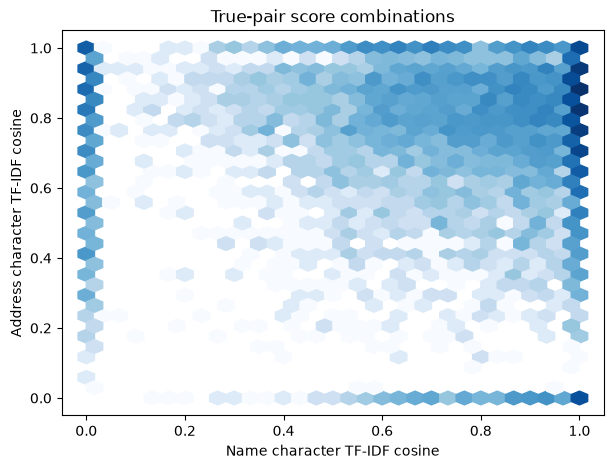

high name + high address


,s1_name,candidate_name,s1_address,candidate_address
648,Elkay Brothers Limited,Sri Elkay Brothers Limited,"2 Saklat Place, 1St Floor, Kolkata, Howrah, We...","West Bengal, H.NO 2 SAKLAT PLACE, 1ST FLOOR, K..."
1394,Oncology Patriot Physicians LLC,Oncology Patriot Physicians,"4708 Fletcher Street, Fl 0, Saint Louis, MO","4708 Fletcher St, SAINT LOUIS, MO"
7142,Clardy and Huang LLC,Clardy and Huang,"24 Fox Run Road, Waterbury, CT","24-D Fox Run Road, Waterbury, Connecticut"
5971,Urban Consulting Private Limited,Urban Consulting Private Limited,"Everest House 12Th Fl46C Chowringhee, Kolkata,...","HN 212 EVEREST HOUSE 12TH FL46C CHOWRINGHEE, K..."
6698,Lifestyle Hospitality (India) Care,Lifestyle Hospitality (India) Care Corp,"Office No 623, 6Th Floor Block A, Tower A2, Wt...","OFFICE NO 623, 6TH FLOOR BLOCK A, TOWER A2, WT..."


high name + low address


,s1_name,candidate_name,s1_address,candidate_address
512,Lockhart Allied Money,Lockhart Allied Money Inc.,"113 Sedgefield Place Lane, Unit F, Winston-sal...","113-A SEDGEFIELD PLACE LANE, WINTSON-SALEM, NC"
7104,Ealey British LLC,Ealey British Llc,"124 11th Street, IA, Unit Suite 2, West Des Mo...","124 1/2 ELEVENTH ST, WEST DES MOINES, IA"
2039,Ballard and Putnam Inc,Ballard and Putnam Inc,"182 Riverside Street, Unit 1, Lowell, MA","162 Riverside Street, # 1, Lwell CITY, Massach..."
3985,Gull Clean Automobile LLC,GULL CLEAN AUTOMOBILE LLC,"2110 Trosper Road, Unit 3, Tumwater, WA","2110. Trosper Rd, # 3, Olypia, Washington"
7073,Hope Finance Private Limited,Hope Finance Private,"Flat No D-320 G/F Pkt Iii, Dda Flat Bindapur, ...","H.no 123 Fat No D-320 G/f Pkt Iii, DL, Delhi, ..."


low name + high address


,s1_name,candidate_name,s1_address,candidate_address
6825,Modern Life Construction Private Limited,मॉडर्न लाइफ कंस्ट्रक्शन प्राइवेट लिमिटेड,"Flat No 707, 7Th Floor Eros Appartment 56 Nehr...","Door No 707, 7Th Floor Eros Appartment 56 Nehr..."
2795,"Middleton, Li and Spero Inc",middletonlispero.com,"718 Harrison Avenue, Canton, OH","18 Harrison Ave, Canton, Ohio"
6700,Dynamic International Private Limited,ડાયનેમિક ઇન્ટરનેશનલ પ્રાઇવેટ લિમિટેડ,"Rajkot, Gujarat, Dhebarbhai Senetorium, Dhebar...","BEHIND METALWOOD FURNITURE, DHEBARBHAI SENETOR..."
338,Go Engineeringprivate Pvt. Ltd.,goengineeringprivate.com,"11, Gaushala Road Village Satbari, Mehrauli, N...","011, Gaushala Road Village Satbari, Mehrauli, ..."
944,Beia Industries LLC,Beia Inufhftrds LLC,"74 600, Midway, UT","74 600, Midway, Utah"


low name + low address


,s1_name,candidate_name,s1_address,candidate_address
452,Foot & Ankle Care Associates,Foot & Aceare Care Associates,"1344 Elmdale Avenue, Chicago, IL","CHICAGO CIY, ELMDALE AVE, IL"
653,Mountain Community LLC,LLC Mountain Community,"38900 Sayer Road, Kenai Peninsula Borough, AK","Sayer Rd, ANCHOR POINT, AK"
3302,Value Aspac LLC,Value Asll LLC,"1025 Hancock Street, Unit 6J, Quincy, MA","1025 Hancokc Saint, # 6J, Quincy, Massachusetts"
4280,Naresh (India) Centre,nareshindiacentre.com,"A 2/5, Renuka Bhakti Apt Near Vithal Mandir Va...","A 2/5, Badlapur, Thane, MH"
6325,Jvm & Partners Limited,Mr Jvm + Ptenrs Limited,"512/652-Ka, 1St Lane Nishatganj, Lucknow, Utta...",


In [9]:
def score_region(frame):
    name_high = frame['name_char_tfidf'] >= .8
    address_high = frame['address_char_tfidf'] >= .7
    return np.select([name_high & address_high, name_high & ~address_high,
                      ~name_high & address_high],
                     ['high name + high address', 'high name + low address',
                      'low name + high address'], default='low name + low address')

positive_features['region'] = score_region(positive_features)
display(positive_features['region'].value_counts().rename('true_pairs').to_frame())
fig, ax = plt.subplots(figsize=(7, 5))
ax.hexbin(positive_features['name_char_tfidf'], positive_features['address_char_tfidf'],
          gridsize=30, mincnt=1, bins='log', cmap='Blues')
ax.set(xlabel='Name character TF-IDF cosine', ylabel='Address character TF-IDF cosine',
       title='True-pair score combinations')
plt.show()
for label, group in positive_features.groupby('region'):
    print(label)
    display(group[['s1_name', 'candidate_name', 's1_address', 'candidate_address']]
            .sample(min(5, len(group)), random_state=SEED))

**How to read this:** Look for real links with a weak name but strong address, and vice versa. The lower-left region deserves manual inspection because both fields are weak. A positive-only plot cannot establish precision; hard negatives provide the comparison next.

## 9. Hard-negative analysis

Retrieve the closest names in the sampled candidate pool, remove all known true links, and retain three non-matches per S1. The ground truth is assumed complete for train S1-to-S2/S3 links. These negatives are deliberately difficult, so they are more informative than random pairs.

In [10]:
def retrieve_topk(X, Y, k):
    neighbors = NearestNeighbors(n_neighbors=min(k, Y.shape[0]), metric='cosine',
                                 algorithm='brute', n_jobs=1).fit(Y)
    # Bound distance-matrix working memory; never build all S1 x candidate scores at once.
    with config_context(working_memory=128):
        distances, indices = neighbors.kneighbors(X, return_distance=True)
    return indices, np.maximum(0, 1 - distances)

name_char_idx, name_char_scores = retrieve_topk(name_char_X, name_char_Y, 50)
true_by_s1 = {s1: set(ids) for s1, ids in sample_truth.items()}
hard_rows = []
for i, s1_id in enumerate(s1_work['entity_id'].astype(str)):
    added = 0
    for j in name_char_idx[i]:
        candidate_id = str(pool_work.iloc[j]['entity_id'])
        if candidate_id not in true_by_s1[s1_id]:
            hard_rows.append((s1_id, candidate_id))
            added += 1
            if added == 3:
                break
hard_links = pd.DataFrame(hard_rows, columns=['s1_entity_id', 'candidate_entity_id'])
hard_pairs = (hard_links.merge(sample_s1.rename(columns={'entity_id': 's1_entity_id',
                                                         'business_name': 's1_name',
                                                         'business_address': 's1_address',
                                                         'country': 's1_country'})
                              [['s1_entity_id', 's1_name', 's1_address', 's1_country']],
                              on='s1_entity_id', validate='many_to_one')
                        .merge(true_pairs[['candidate_entity_id', 'candidate_name', 'candidate_address',
                                           'candidate_country', 'candidate_source']]
                               .drop_duplicates('candidate_entity_id'), on='candidate_entity_id', how='left'))
# A hard negative may be a background candidate with no positive relationship.
missing = hard_pairs['candidate_name'].isna()
if missing.any():
    lookup = pool_work.set_index('entity_id')
    for dest, source_col in [('candidate_name', 'business_name'),
                             ('candidate_address', 'business_address'),
                             ('candidate_country', 'country'),
                             ('candidate_source', 'candidate_source')]:
        hard_pairs.loc[missing, dest] = hard_pairs.loc[missing, 'candidate_entity_id'].map(lookup[source_col])
hard_features = pair_features(hard_pairs)
feature_cols = ['name_char_tfidf', 'name_word_tfidf', 'name_levenshtein', 'name_jaro_winkler',
                'address_char_tfidf', 'address_token_jaccard', 'numeric_overlap',
                'address_containment', 'country_agreement']
comparison = pd.concat([positive_features[feature_cols].assign(label='true'),
                        hard_features[feature_cols].assign(label='hard negative')])
display(comparison.groupby('label')[feature_cols].agg(['count', 'median', 'mean']).round(3))
display(hard_features.nlargest(MAX_EXAMPLES, 'name_char_tfidf')
        [['s1_name', 'candidate_name', 's1_address', 'candidate_address',
          'name_char_tfidf', 'address_char_tfidf', 'numeric_overlap']])

name_char_tfidf               name_word_tfidf                \
                        count median   mean           count median   mean   
label                                                                       
hard negative            6450  0.570  0.589            6450  0.423  0.440   
true                     7609  0.814  0.722            7609  0.803  0.668   

              name_levenshtein               name_jaro_winkler  ...  \
                         count median   mean             count  ...   
label                                                           ...   
hard negative             6450  0.611  0.613              6450  ...   
true                      7609  0.808  0.729              7609  ...   

              address_token_jaccard numeric_overlap                \
                               mean           count median   mean   
label                                                               
hard negative                 0.016            6450    0.0  0.004   
true                          0.600            7609    1.0  0.668   

              address_containment               country_agreement         \
                            count median   mean             count median   
label                                                                      
hard negative                6450    0.0  0.035              6450    1.0   
true                         7609    0.8  0.763              7609    1.0   

                      
                mean  
label                 
hard negative  0.925  
true           1.000  

[2 rows x 27 columns]

,s1_name,candidate_name,s1_address,candidate_address,name_char_tfidf,address_char_tfidf,numeric_overlap
1677,Ridge Veterinary Clinic,Ridge Veterinary Clinic,"3351 Little Horsethief Canyon Road, Hesperia, CA","1926 Ridgegate Lane, SIMI Valley, California",1.0,0.004439,0.000000
2169,Shivam Technologies,Shivam Technologies,"No.6/1, Next To Legacy School, Opp Nanjundeshw...",,1.0,0.000000,0.000000
2736,Redwood,#redwood,"200 Ohio Street, Waynesfield, OH","680 SHELBY TRL, CONWAY, AR",1.0,0.006798,0.000000
2737,Redwood,Redwood,"200 Ohio Street, Waynesfield, OH","TREVENIA STREET, BLACLKICK CITY, OH",1.0,0.082887,0.000000
2738,Redwood,Redwood,"200 Ohio Street, Waynesfield, OH","1285 Andrus St, Akron, Ohio",1.0,0.060168,0.000000
3078,"Cornerstone, LLC",CORNERSTONE LLC,"10044 Paxton Avenue, Chicago, IL","151- SHADOW LN, AR, AUSTIN",1.0,0.006901,0.000000
3180,Prairie Trust,>> Prairie Trust,"1001 Adamant Road, Calais, VT","##5426 Fairgrove Lane, West Valley City, Utah",1.0,0.000000,0.000000
3387,Downtown Coffee!,Downtown Coffee,"Unit 12, Washington, 602 46th Place, DC","115 Harvey St, CAMBRIDGE, MA",1.0,0.000000,0.000000
3388,Downtown Coffee!,Downtown-Coffee,"Unit 12, Washington, 602 46th Place, DC","##22 Harvest Ridge Rd, Selkirk DP, New York",1.0,0.000000,0.000000
4368,"Primary Care Physicians, LLC",Primary Care Physicians LLC,"117 Tolman Street, Westbrook, ME","330- Jade St, North Dakota, Dickinson",1.0,0.002327,0.000000


**How to read this:** Compare true and hard-negative medians, especially where name scores overlap. Inspect near-identical names at different addresses, chains, generic names, and address reuse. A useful matcher must separate these cases; random negatives would make the task look easier than it is.

## 10. Duplicate and ambiguous business names

Count repeated normalized names in the sampled candidate pool and inspect their address diversity. These are sample frequencies, not corpus-wide frequencies.

In [11]:
name_groups = (pool_work.groupby('name_norm', dropna=False)
               .agg(records=('entity_id', 'size'), distinct_addresses=('address_norm', 'nunique'),
                    sources=('candidate_source', lambda x: ','.join(sorted(set(x)))))
               .sort_values('records', ascending=False))
display(name_groups.head(25))
ambiguous = name_groups[(name_groups['records'] > 1) & (name_groups['distinct_addresses'] > 1)]
print('Repeated sampled names at distinct addresses:', len(ambiguous))
display(pool_work.loc[pool_work['name_norm'].isin(ambiguous.head(5).index),
                      ['entity_id', 'business_name', 'business_address', 'country', 'candidate_source']]
        .sort_values('business_name').head(30))
print('Hard negatives with exact normalized names:', int(hard_features['name_exact'].sum()),
      'of', len(hard_features))

,records,distinct_addresses,sources
name_norm,,,
womens health,16,16,"S2,S3"
urgent care,14,14,"S2,S3"
primary care,12,12,"S2,S3"
physical therapy,11,11,"S2,S3"
straight edge,10,9,"S2,S3"
pediatric dental,8,8,"S2,S3"
office of,8,8,"S2,S3"
urology care,7,7,S2
स वन सर व स ज प र इव ट ल म ट ड,7,7,"S2,S3"


Repeated sampled names at distinct addresses: 2804


,entity_id,business_name,business_address,country,candidate_source
87322,S3-946509018,Physical Therapy,"4401 53th Street, Chicago, Illinois",US,S3
30549,S2-466961285,Physical Therapy,"3042-3044 REGAL CT, FRUITVALE, CO",US,S2
47315,S2-747679105,Physical Therapy,"1400. 6TH STREET, MARION TWP, OH",US,S2
110244,S3-45017217,Physical Therapy,"10 Jadecrest Court, Conroe, Texas",US,S3
35085,S2-961486019,Physical Therapy,"NE, OMAHA, 4220D G STREET",US,S2
29467,S2-770172128,Physical Therapy,"57 COBURN TER, EVERETT, MA",US,S2
16585,S2-288404545,Physical Therapy,"154 1287, GRAHAM, TX",US,S2
109748,S3-562752622,Physical Therapy,"2317 Monument Avenue, Richmond, Virginia",US,S3
65900,S3-515545220,Physical Therapy,"2104 Sunhaven Circle, Fairfield, California",US,S3
4187,S2-895858451,Physical Therapy,"7625 SEVENTH STREET, PHOENNIX, AZ",US,S2


Hard negatives with exact normalized names: 240 of 6450


**How to read this:** Repeated names at different addresses suggest branch or generic-name ambiguity. Check how often the hard negatives have exactly the same normalized name. If common, exact-name equality needs address or other corroboration; this sampled count does not measure population prevalence.

## 11. Source-wise comparison

Compare positive and hard-negative scores by the candidate's source. Source differences can justify including the source as a feature, but do not by themselves require separate models.

In [12]:
source_cols = ['name_char_tfidf', 'address_char_tfidf', 'numeric_overlap',
               'address_length_ratio', 'country_agreement']
source_comparison = pd.concat([positive_features.assign(label='true'),
                               hard_features.assign(label='hard negative')])
display(source_comparison.groupby(['label', 'candidate_source'])[source_cols]
        .agg(['count', 'median', 'mean']).round(3))
display(overview.loc[[('train', 'S2'), ('train', 'S3')],
                     ['missing_name_pct', 'missing_address_pct', 'avg_name_chars',
                      'avg_address_chars']].round(2))

name_char_tfidf                \
                                         count median   mean   
label         candidate_source                                 
hard negative S2                          3076  0.569  0.586   
              S3                          3374  0.572  0.592   
true          S2                          3761  0.832  0.722   
              S3                          3848  0.797  0.723   

                               address_char_tfidf                \
                                            count median   mean   
label         candidate_source                                    
hard negative S2                             3076  0.003  0.017   
              S3                             3374  0.003  0.015   
true          S2                             3761  0.829  0.766   
              S3                             3848  0.769  0.706   

                               numeric_overlap                \
                                         count median   mean   
label         candidate_source                                 
hard negative S2                          3076    0.0  0.003   
              S3                          3374    0.0  0.005   
true          S2                          3761    1.0  0.656   
              S3                          3848    1.0  0.680   

                               address_length_ratio                \
                                              count median   mean   
label         candidate_source                                      
hard negative S2                               3076  0.786  0.730   
              S3                               3374  0.745  0.691   
true          S2                               3761  0.903  0.842   
              S3                               3848  0.870  0.789   

                               country_agreement                
                                           count median   mean  
label         candidate_source                                  
hard negative S2                            3076    1.0  0.923  
              S3                            3374    1.0  0.926  
true          S2                            3761    1.0  1.000  
              S3                            3848    1.0  1.000

missing_name_pct  missing_address_pct  avg_name_chars  \
split source                                                          
train S2                   0.0                 3.36            25.1   
      S3                   0.0                 3.33            25.2   

              avg_address_chars  
split source                     
train S2                  46.23  
      S3                  46.71

**How to read this:** Compare S2 and S3 with their denominators. If one source has weaker names or addresses, candidate source may help calibration and retrieval choice. Apparent differences can also reflect how many positive links each source contributes.

## 12. Country and train-test comparison

These statistics use every record. Country labels remain open-ended, so test-only countries appear automatically.

In [13]:
country_rows = []
for (split, source), groups in country_sums.items():
    for country, counts in groups.items():
        n = counts['rows']
        country_rows.append({'split': split, 'source': f'S{source}', 'country': country,
                             'rows': n,
                             'missing_name_pct': 100 * counts['missing_name'] / n,
                             'missing_address_pct': 100 * counts['missing_address'] / n,
                             'avg_name_chars': counts['name_chars'] / n,
                             'avg_address_chars': counts['address_chars'] / n,
                             'avg_name_tokens': counts['name_tokens'] / n,
                             'avg_address_tokens': counts['address_tokens'] / n,
                             'avg_numeric_tokens': counts['numeric_tokens'] / n,
                             'non_ascii_pct': 100 * counts['non_ascii'] / n})
country_overview = pd.DataFrame(country_rows).sort_values(['split', 'source', 'rows'], ascending=[True, True, False])
display(country_overview.round(2))
display(pd.crosstab(country_overview['country'], country_overview['split'],
                    values=country_overview['rows'], aggfunc='sum').fillna(0).astype(int))
display(positive_features.groupby('s1_country')[['name_char_tfidf', 'address_char_tfidf',
                                                   'numeric_overlap']].agg(['count', 'median']).round(3))

,split,source,country,rows,missing_name_pct,missing_address_pct,avg_name_chars,avg_address_chars,avg_name_tokens,avg_address_tokens,avg_numeric_tokens,non_ascii_pct
7,test,S1,India,809986,0.0,0.00,26.37,77.71,3.74,11.23,1.61,0.06
8,test,S1,US,663106,0.0,0.00,22.46,34.97,3.42,5.90,1.18,0.00
6,test,S1,France,259452,0.0,0.00,19.42,50.07,3.11,7.22,1.02,38.93
10,test,S2,India,2312565,0.0,2.28,28.25,68.75,3.82,10.17,1.72,44.77
11,test,S2,US,1871330,0.0,2.94,24.29,31.84,3.48,5.48,1.05,6.25
9,test,S2,France,703378,0.0,3.06,21.10,39.55,3.10,6.19,0.94,42.40
13,test,S3,India,2405000,0.0,2.46,27.87,59.42,3.80,9.18,1.59,36.75
14,test,S3,US,1945701,0.0,2.84,24.62,38.84,3.53,5.94,1.15,6.40
12,test,S3,France,731615,0.0,2.94,21.14,39.97,3.11,6.23,0.94,42.15
1,train,S1,US,1323633,0.0,0.00,22.47,34.96,3.42,5.90,1.18,0.00


split,test,train
country,,
France,1694445,0
India,5527551,5016534
US,4480137,7510506


name_char_tfidf        address_char_tfidf        numeric_overlap  \
                     count median              count median           count   
s1_country                                                                    
India                 3131  0.743               3131  0.853            3131   
US                    4478  0.845               4478  0.769            4478   

                   
           median  
s1_country         
India         1.0  
US            1.0

**How to read this:** Compare train and test within each source and country. France has no training labels, so its feature distribution can be inspected but its matching quality cannot be measured here. Large shifts in non-ASCII text, lengths, or number patterns favor Unicode-safe, country-agnostic features and careful validation.

## 13. Simple candidate-generation experiment

Evaluate top-K name character, name word, address character, and name/address union retrieval. All sampled true partners were inserted into the candidate pool, so recall here measures ranking **within the sampled pool** and can overstate full-corpus recall. Do not choose production K from this table alone.

In [14]:
name_word_idx, name_word_scores = retrieve_topk(name_word_X, name_word_Y, 50)
address_idx, address_scores = retrieve_topk(addr_char_X, addr_char_Y, 50)
retrieval = {'name_char': name_char_idx, 'name_word': name_word_idx, 'address_char': address_idx}
positive_id_pairs = set(zip(true_pairs['s1_entity_id'].astype(str),
                            true_pairs['candidate_entity_id'].astype(str)))
def evaluate_candidates(method, k):
    selected = []
    for i, s1_id in enumerate(s1_work['entity_id'].astype(str)):
        if method == 'name_address_union':
            indices = set(name_char_idx[i, :k]) | set(address_idx[i, :k])
        else:
            indices = set(retrieval[method][i, :k])
        selected.append({str(pool_work.iloc[j]['entity_id']) for j in indices})
    caught = sum(candidate_id in selected[s1_index[s1_id]] for s1_id, candidate_id in positive_id_pairs)
    sizes = np.array([len(x) for x in selected])
    row = {'method': method, 'K': k, 'true_pairs': len(positive_id_pairs),
           'recall_pct': 100 * caught / len(positive_id_pairs),
           'avg_candidates': sizes.mean(), 'median_candidates': np.median(sizes),
           'p95_candidates': np.percentile(sizes, 95), 'max_candidates': sizes.max(),
           'reduction_ratio': 1 - sizes.mean() / len(pool_work)}
    for source in ('S2', 'S3'):
        subset = true_pairs.loc[true_pairs['candidate_source'].eq(source)]
        row[f'{source}_recall_pct'] = 100 * np.mean([
            candidate_id in selected[s1_index[s1_id]] for s1_id, candidate_id in
            zip(subset['s1_entity_id'].astype(str), subset['candidate_entity_id'].astype(str))]) if len(subset) else np.nan
    return row, selected

retrieval_rows = []
candidate_sets = {}
for method in ('name_char', 'name_word', 'address_char', 'name_address_union'):
    for k in (5, 10, 20, 50):
        row, selected = evaluate_candidates(method, k)
        retrieval_rows.append(row)
        candidate_sets[(method, k)] = selected
retrieval_table = pd.DataFrame(retrieval_rows).sort_values(['method', 'K'])
display(retrieval_table.round(3))

,method,K,true_pairs,recall_pct,avg_candidates,median_candidates,p95_candidates,max_candidates,reduction_ratio,S2_recall_pct,S3_recall_pct
8,address_char,5,7609,85.412,5.000,5.0,5.0,5,1.000,88.540,82.354
9,address_char,10,7609,90.932,10.000,10.0,10.0,10,1.000,93.034,88.877
10,address_char,20,7609,92.193,20.000,20.0,20.0,20,1.000,93.858,90.567
11,address_char,50,7609,93.692,50.000,50.0,50.0,50,1.000,94.709,92.698
12,name_address_union,5,7609,95.334,7.766,8.0,10.0,10,1.000,96.171,94.517
13,name_address_union,10,7609,98.147,17.395,17.0,20.0,20,1.000,98.458,97.843
14,name_address_union,20,7609,98.725,37.238,37.0,40.0,40,1.000,98.857,98.597
15,name_address_union,50,7609,99.198,97.061,97.0,100.0,100,0.999,99.335,99.064
0,name_char,5,7609,72.966,5.000,5.0,5.0,5,1.000,73.571,72.375
1,name_char,10,7609,80.668,10.000,10.0,10.0,10,1.000,80.378,80.951


**How to read this:** Look for a K where recall gains flatten while candidate counts still grow. Compare retrieval methods and their union, including S2/S3 recalls. Because background distractors are sampled, these recall numbers are optimistic; a full-corpus retrieval run is needed before setting blocking for a model.

## 14. Analyze missed candidate pairs

Show positives missed by representative retrieval methods. These examples reveal whether a second field, alternate normalization, or a larger K may help.

In [15]:
for method, k in [('name_char', 20), ('address_char', 20), ('name_address_union', 20)]:
    selected = candidate_sets[(method, k)]
    missed = positive_features.loc[[str(candidate_id) not in selected[s1_index[str(s1_id)]]
                                    for s1_id, candidate_id in zip(positive_features['s1_entity_id'],
                                                                    positive_features['candidate_entity_id'])]]
    print(f'{method} K={k}: {len(missed):,} missed of {len(positive_features):,} sampled true links')
    display(missed[['s1_name', 'candidate_name', 's1_address', 'candidate_address',
                    'candidate_source', 'name_char_tfidf', 'address_char_tfidf']]
            .sample(min(20, len(missed)), random_state=SEED) if len(missed) else missed)

name_char K=20: 1,214 missed of 7,609 sampled true links


,s1_name,candidate_name,s1_address,candidate_address,candidate_source,name_char_tfidf,address_char_tfidf
7219,F+ First,F+ (Fírst),"4612 Campbell Street, Kansas City, MO","CAMPBELL ST, KANSAS CITY TOWNSHIP, MO",S2,0.114135,0.589959
4734,Ridge Federation,Ridge Partners,"1683 Dorset Drive, Avon, IN","##1683 DORSET DRIVE, AVON, IN",S2,0.270357,1.000000
3183,Raj Services Limited,রাজ সার্ভিসেস লিমিটেড,"2, Gandhi Colony, Kolkata, Kolkata, Howrah, We...","2, KOLKATA, HOWRAH, West Bengal",S2,0.000000,0.717346
4217,Sree Management Limited,Sree Limited [Service],"No 16/64, Thambiya Chetty Road West Mambalam, ...","No 16/64, Chennai, தமிழ்நாடு",S3,0.208981,0.306257
4936,S+ Resilience LLC,S+ Rielsieenc-LLC,"16823 Ottawa Drive, Lockport, IL","16823-16827 OTTAWA DR, LOCKPORT, IL",S2,0.056705,0.773023
4989,Gujarat Investment,ગુજરાત ઇન્વેસ્ટમેન્ટ,"Gf-8 Ekta Tower, Barage Road, Vasna, Ahmedabad...","BLOCK B-420 GF-8 EKAT TOWER, VASNA, AHMEDABAD,...",S2,0.000000,0.567619
608,Om Logistics Private Limited,ॐ लॉजिस्टिक्स प्राइवेट लिमिटेड,"Office No. 404 To 407, 4Th Floor, Imperial Pla...","OFFICE NO. 404 TO 407, BOMBAY, MUMBAI, Maharas...",S2,0.000000,0.463127
2144,Chiropractic Medicine Inc,chíropracticmedicine.com,"DE, Bear, Unit B, 1020 Sarah Leak Boulevard","1020 Sarah Leak Boulevard, # B, Bear, Delaware",S3,0.459650,0.681205
4371,Strategic Tsakos Inc,Strategic Inc (Partners),"28440 Kalisher Road, Helendale, CA","28440 Kalisher Road, Helendale, California",S3,0.355798,0.913755
1148,Urgent Care Medicine LLC,Urgent Care Mleteidrnie LLC,"17821 8th Avenue, Shoreline, WA","Shoreline, 17821 Eighth Ave, Washington",S3,0.491021,0.478641


address_char K=20: 594 missed of 7,609 sampled true links


,s1_name,candidate_name,s1_address,candidate_address,candidate_source,name_char_tfidf,address_char_tfidf
1970,Galaxy Consulting Private Limited,ಗ್ಯಾಲಕ್ಸಿ ಕನ್ಸಲ್ಟಿಂಗ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"#479, Nanjappa Layout 7Th Cross, Koramangala 8...","DOOR NO ##479, BANGALORE, Karnataka",S2,0.000000,0.316866
1390,North Producer,नॉर्थ प्रोड्यूसर,"Maharashtra, A-303, Navkar Chambers Co-Op Prem...","A-303, BOMBAY, MUMBAI CITY, Maharashtra",S2,0.000000,0.269519
330,Yaduvanshi (India) Decor Private Limited,Private Yaduvanshi (India) Decor Limited,"Delhi, East Delhi, Delhi, 235, First Floor, Sa...","235, Delhi, DL",S3,0.834259,0.254779
1746,Hcl (India) Stores Private Limited,Hcl (India) Stores Private Ltd,"Maharashtra, H. No. 32 At Post Kolnur, Osmanab...",,S3,1.000000,0.000000
6959,Schaefer Pinnacle Art,Schaefer Pinnacle Art Co,"3102 28, Webb, NY",,S3,0.939914,0.000000
990,Office of Public Works,Office of Public Works Works,"7S 471 Old College Road, Naperville, IL",,S2,0.903096,0.000000
6344,Empire Holdings Group LLC,Empire Holdings Group LLC,"10827 Gambril Drive, Unit UNIT 12, Prince Will...","10827 GAMBRIL DRIVE, MANASSAS, VA",S2,1.000000,0.414869
490,Premier Foods Private Limited,Sri Premier Foods Private Limited,"#2934/B, D Block, Rajajinagar 2Nd Stage., Bang...",,S3,0.860252,0.000000
4161,Royal Infra Limited,রয়্যাল ইনফ্রা লিমিটেড,"207, A. J. C. Bose Road, 2Nd Floor, Kolkata, H...","207, HOWRAH, KOLKATTA, West Bengal",S2,0.000000,0.371759
3312,Shabbir Holdings,Wextavo,"18, Rabindra Sarani, Poddar Court, Gate No.2, ...","PLOT B3/697 18, HOWRAH, পশ্চিমবঙ্গ",S2,0.000000,0.077588


name_address_union K=20: 97 missed of 7,609 sampled true links


,s1_name,candidate_name,s1_address,candidate_address,candidate_source,name_char_tfidf,address_char_tfidf
7534,Shyam Care Private Limited,Shyam Private Limited Services - 2716775727,"Bl-A, Ist Fr, Fl-1B, 167-B(Hld-544/1) Lake Tow...","Bl-a, Kolkata, পশ্চিমবঙ্গ",S3,0.287296,0.252109
723,Sun Enterprises LLP,சன் எண்டர்பிரைசஸ் எல்எல்பி,"34/935, 69Th Street, 11Th Sector, K K Nagar, C...","Chennai, 34/935, தமிழ்நாடு, Chennai",S3,0.000000,0.286802
485,Miller and Miller Eco LLC,LYRAVIO,"511 10th Street, Tempe, AZ","511C 10RD ST, TEMPE TOWNSHIP, AZ",S2,0.000000,0.299751
1532,Galaxy Galaxy Software Private Limited,गैलेक्सी गैलेक्सी सॉफ्टवेयर Private Limited,"B-4, Agfa Building, Nr.Vardhaman Nagar, Dr. R ...","Plot 00491 B-4, Greater Bombay, MH",S3,0.029374,0.035533
7315,United Coalition,United Cóalition,"8926 Greenspointe Lane, Highlands Ranch, CO",,S2,0.531544,0.000000
1154,Al Andresorts Private Limited,Limited Al Private Service,"A-191, Second Floor, New Delhi, South Delhi, D...","<NULL>, New Delhi, South Delhi, #311 A-191, DL",S3,0.044057,0.550798
577,New Delhi Solutions Private Limited,New Delhi Private Limited (Service),"1017, Barakhamba Tower, 22 Barakhamba Road, Ne...",,S2,0.506983,0.000000
5974,CY Ventures Private Limited,Private CY Véntures Limited,"Flat No -107, Narayanadri Towers, Complex Rd.N...","NO. 629 FLAT NO -107, HYDERABAD, Andhra Pradesh",S2,0.342712,0.204702
4983,Tech Sai Enterprises Limited,ಟೆಕ್ ಸಾಯಿ ಎಂಟರ್‌ಪ್ರೈಸಸ್ ಲಿಮಿಟೆಡ್,"G-15, Rajguru Plaza, 263/64, Old Tharagupet, B...","G-15, Bangalore, KA",S3,0.000000,0.361838
1914,Krishna Consultants Private Limited,ಕೃಷ್ಣ ಕನ್ಸಲ್ಟೆಂಟ್ಸ್ ಪ್ರೈವೇಟ್ ಲಿಮಿಟೆಡ್,"Bangalore, Karnataka, 9Th Main, Sector 6, Bang...","161, BANGALORE SOUTH, BANGALORE, ಕರ್ನಾಟಕ",S2,0.000000,0.421877


**How to read this:** Ask whether the missed name is corrupted, an address is missing, or transliteration is involved. Check whether the union rescues cases missed by a single retrieval method. Remaining misses are especially useful when designing the next blocking experiment.

## 15. Singleton exploration

Compare top retrieved scores for sampled S1 singletons and non-singletons. This is an exploratory score comparison, not a calibrated decision threshold.

top_name_score               top_address_score                \
                   count median   mean             count median   mean   
singleton                                                                
False               2049  1.000  0.948              2049  0.906  0.879   
True                 101  0.625  0.652               101  0.506  0.504   

          best_combined_among_name_top10               name_top1_top2_gap  \
                                   count median   mean              count   
singleton                                                                   
False                               2049  0.890  0.857               2049   
True                                 101  0.327  0.342                101   

                         
          median   mean  
singleton                
False      0.056  0.100  
True       0.038  0.057

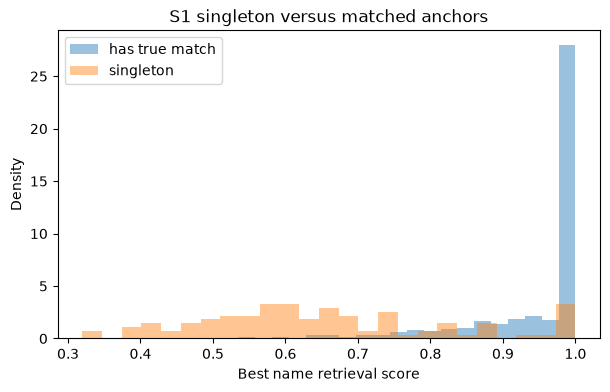

In [16]:
singleton_rows = []
top_for_combined = min(10, name_char_idx.shape[1])
combined_left_ids = np.repeat(s1_work['entity_id'].astype(str).to_numpy(), top_for_combined)
combined_right_ids = np.array([[str(pool_work.iloc[j]['entity_id']) for j in row[:top_for_combined]]
                               for row in name_char_idx]).ravel()
combined_address_scores = row_cosines(addr_char_X, addr_char_Y,
                                      combined_left_ids, combined_right_ids).reshape(len(s1_work), top_for_combined)
for i, s1_id in enumerate(s1_work['entity_id'].astype(str)):
    name_top = name_char_scores[i]
    address_top = address_scores[i]
    combined = sorted((float(name_top[j]) + float(combined_address_scores[i, j])) / 2
                      for j in range(top_for_combined))
    singleton_rows.append({'s1_entity_id': s1_id, 'singleton': len(sample_truth[s1_id]) == 0,
                           'top_name_score': float(name_top[0]),
                           'top_address_score': float(address_top[0]),
                           'best_combined_among_name_top10': combined[-1] if combined else np.nan,
                           'name_top1_top2_gap': float(name_top[0] - name_top[1]) if len(name_top) > 1 else np.nan})
singleton_scores = pd.DataFrame(singleton_rows)
display(singleton_scores.groupby('singleton')
        [['top_name_score', 'top_address_score', 'best_combined_among_name_top10',
          'name_top1_top2_gap']].agg(['count', 'median', 'mean']).round(3))
fig, ax = plt.subplots(figsize=(7, 4))
for label, group in singleton_scores.groupby('singleton'):
    ax.hist(group['top_name_score'], bins=25, density=True, alpha=.45,
            label='singleton' if label else 'has true match')
ax.set(xlabel='Best name retrieval score', ylabel='Density', title='S1 singleton versus matched anchors')
ax.legend()
plt.show()

**How to read this:** If singleton and matched S1 score distributions overlap, a simple nearest-neighbor cutoff is unlikely to work well. A larger separation suggests score calibration may help. Remember that the sampled candidate pool makes these nearest-neighbor scores different from full-corpus scores.

## What to conclude after running this notebook

Fill these answers from the generated outputs; leave a question open if the evidence is too weak.

1. What percentage of S1 records have no match?
2. Are multiple matches common?
3. Which source is noisier: S2 or S3?
4. Which name normalization steps appear useful, and which cause collisions?
5. How strong is name similarity for true matches?
6. How strong is address similarity?
7. Are numeric address tokens useful?
8. What types of true matches are hardest?
9. What makes hard negatives deceptive?
10. Are duplicate business names common?
11. Can name and address compensate for each other?
12. Is there meaningful train/test shift?
13. Does France look structurally different from training countries?
14. Which candidate approach has the strongest **sample-pool** recall?
15. Which true matches are still missed?
16. Do singletons appear separable from matched entities?

Before selecting blocking K or a match threshold for the actual challenge, validate retrieval against the full S2/S3 corpus and evaluate on a held-out S1 set. The sample-pool results above are for understanding patterns and debugging candidate logic.